In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [103]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [104]:
pd.set_option("display.max_columns", None)

In [105]:
sns.set(style="whitegrid")

In [106]:
df = pd.read_csv('german_credit_data.csv')

In [107]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [108]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [109]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [111]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
df["Job"].unique()

array([2, 1, 3, 0])

In [113]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [114]:
df.duplicated().sum()

np.int64(0)

In [115]:
df=df.dropna().reset_index(drop=True)

In [116]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [117]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [118]:
df.drop(columns='Unnamed: 0', inplace =True)

In [119]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,40,male,3,own,little,little,3857,30,car,good
520,23,male,2,free,little,little,1845,45,radio/TV,bad


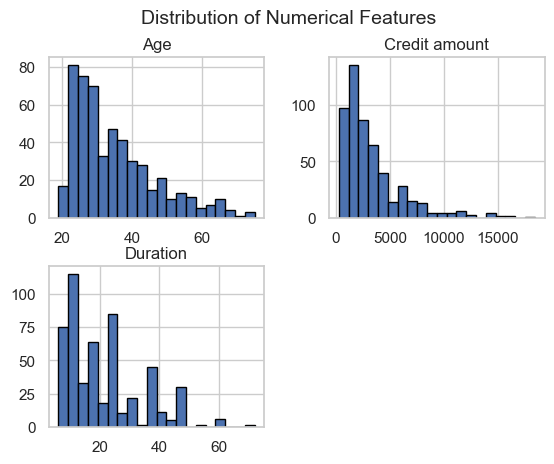

In [120]:
df[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Features",fontsize=14)
plt.show()

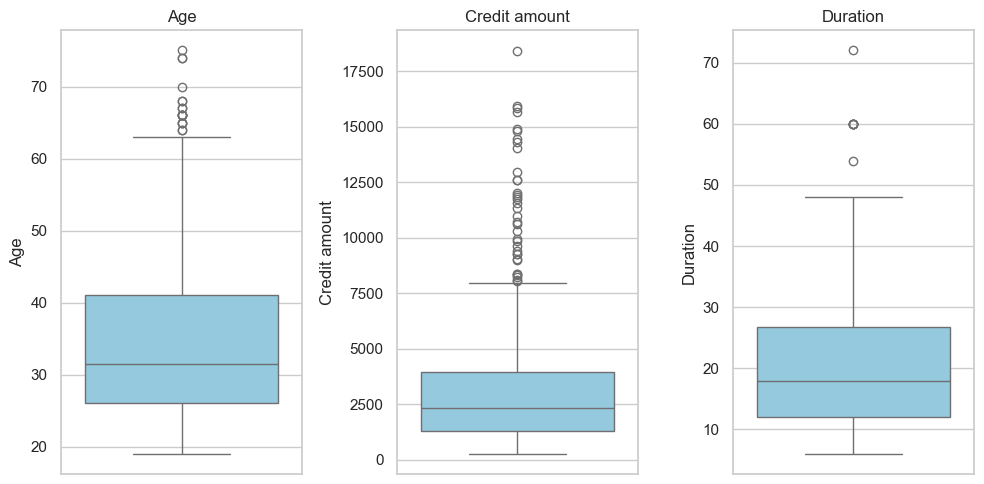

In [121]:
plt.figure(figsize=(10, 5))
for i , col in enumerate(["Age","Credit amount","Duration"]):
  plt.subplot(1,3,i+1)
  sns.boxplot(y=df[col],color="skyblue")
  plt.title(col)

plt.tight_layout()
plt.show()

In [122]:
df.query("Duration>=60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [123]:
categorical_cols=["Sex","Job","Housing","Saving accounts",'Checking account',"Purpose"]

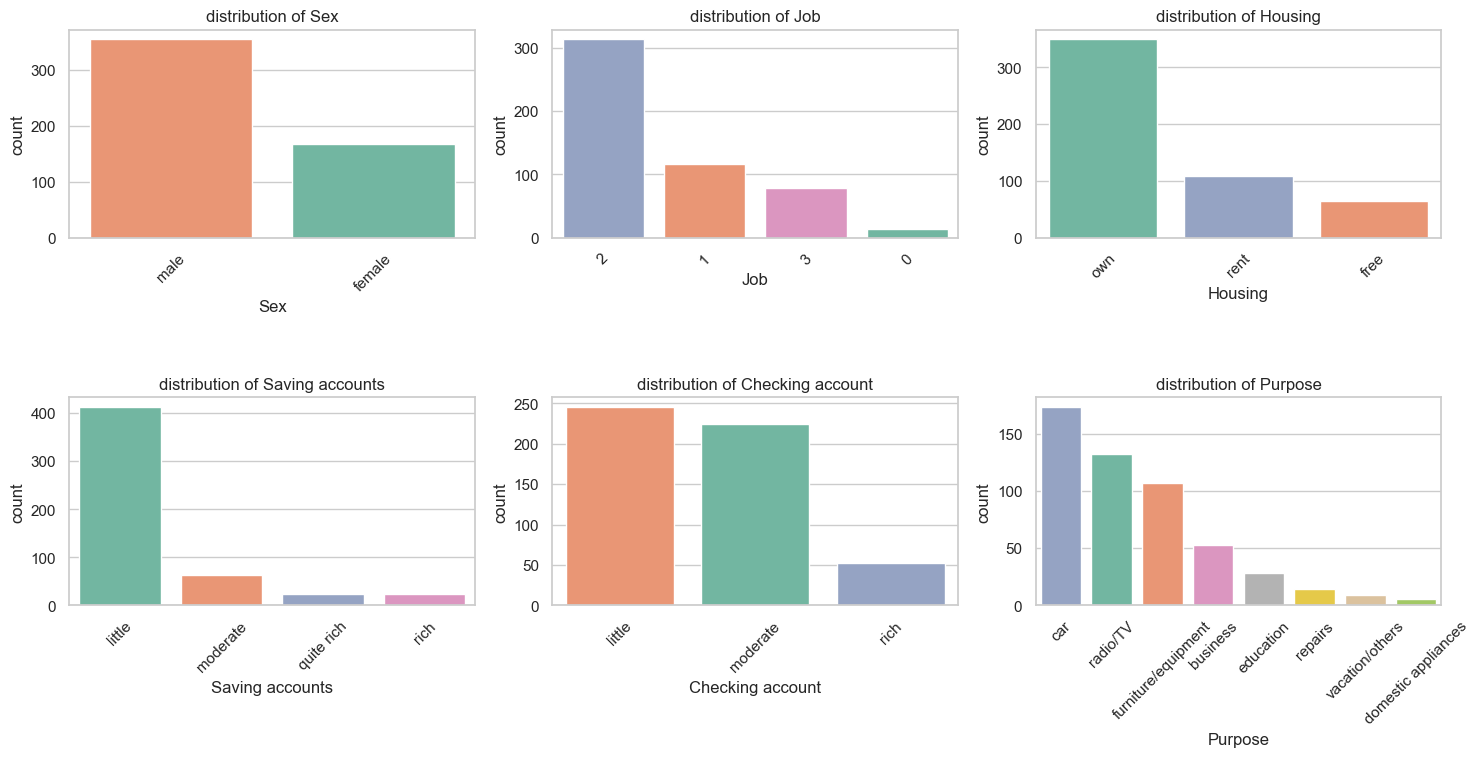

In [124]:
plt.figure(figsize=(15, 10))
for i , col in enumerate(categorical_cols):
  plt.subplot(3,3,i+1)
  sns.countplot(data=df,x=col,palette="Set2",order=df[col].value_counts().index, hue=col, legend=False)

  plt.title(f"distribution of {col}")
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [125]:
corr=df[["Age","Job","Credit amount","Duration"]].corr()

In [126]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


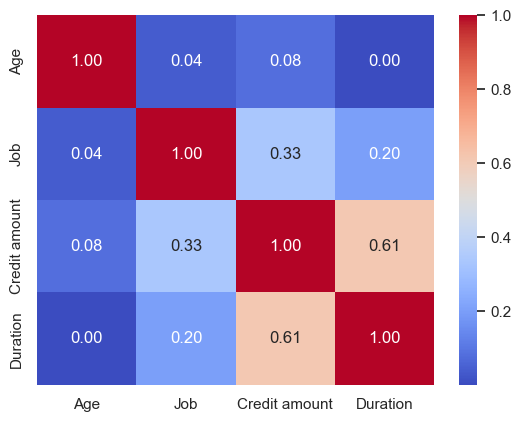

In [127]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [128]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [129]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [130]:
pd.pivot_table(df,values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


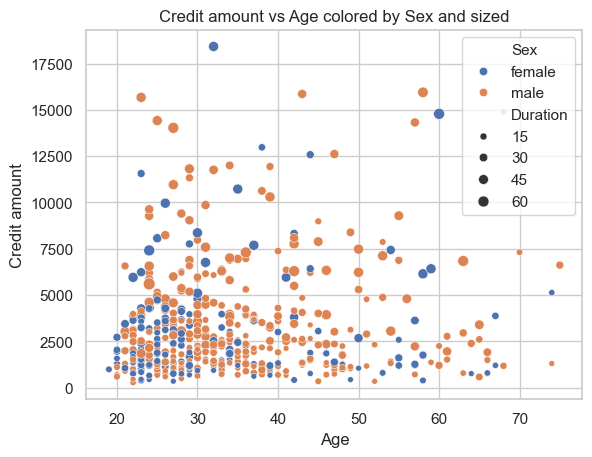

In [131]:
sns.scatterplot(data=df,x="Age",y="Credit amount",hue="Sex",size="Duration")
plt.title("Credit amount vs Age colored by Sex and sized")
plt.show()

C:\Users\RITAM\AppData\Local\Temp\ipykernel_17340\3668672400.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="Saving accounts",y="Credit amount", palette="Pastel1")


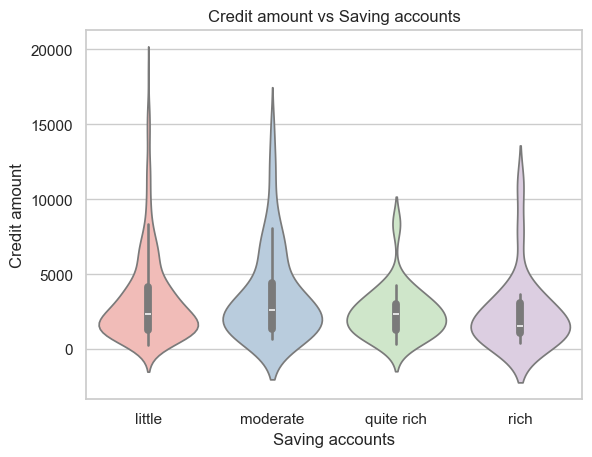

In [132]:
sns.violinplot(data=df,x="Saving accounts",y="Credit amount", palette="Pastel1")
plt.title("Credit amount vs Saving accounts")
plt.show()

In [133]:
display(df["Risk"].value_counts(normalize=True)*100)

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

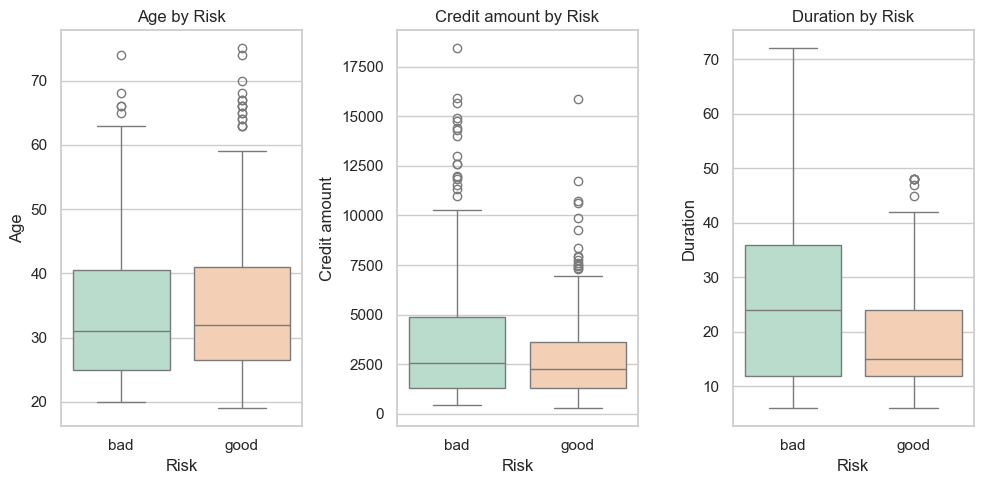

In [134]:
plt.figure(figsize= ( 10,5))
for i, col in enumerate( ["Age","Credit amount","Duration"]):
  plt.subplot(1,3, i+1)
  sns.boxplot(data = df, x = "Risk", y = col, palette="Pastel2", hue="Risk", legend=False)
  plt.title(f"{col} by Risk")
plt.tight_layout()
plt.show()

In [135]:
df.groupby("Risk") [["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [136]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

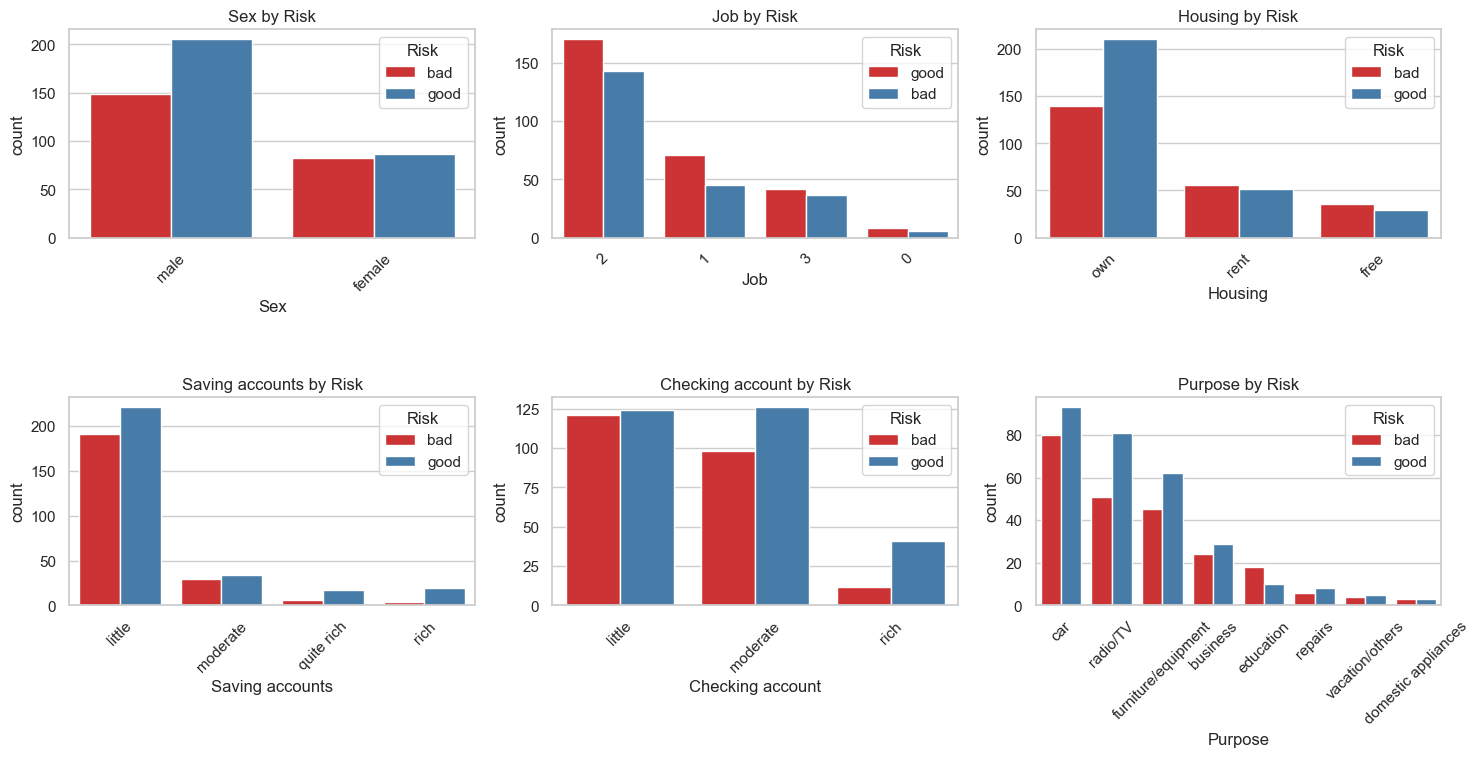

In [137]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data = df, x = col, hue = "Risk", palette = "Set1", order =df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [138]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [139]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration","Purpose"]

In [140]:
target="Risk"

In [141]:
df_model = df[features + [target]].copy()

In [142]:
display(df_model.head())

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


In [143]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [144]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk")

In [145]:
le_dict ={}

In [146]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [147]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"fcolt_encoder.pkl")

In [148]:
le_target = LabelEncoder()

In [149]:
target

'Risk'

In [150]:
df_model[target] = le_target.fit_transform(df_model[target])

In [151]:
df_model [target]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [152]:
df_model [target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [153]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,0,2,1,0,1,5951,48,5,0
1,45,1,2,0,0,0,7882,42,4,1
2,53,1,2,0,0,0,4870,24,1,0
3,35,1,3,2,0,1,6948,36,1,1
4,28,1,3,1,0,1,5234,30,1,0


In [154]:
from sklearn.model_selection import train_test_split

In [155]:
X = df_model.drop(target, axis = 1)

In [156]:
y = df_model[target]

In [157]:
df ["Saving accounts"].unique()

array(['little', 'moderate', 'quite rich', 'rich'], dtype=object)

In [158]:
df ["Checking account"].unique()

array(['moderate', 'little', 'rich'], dtype=object)

In [159]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,22,0,2,1,0,1,5951,48,5
1,45,1,2,0,0,0,7882,42,4
2,53,1,2,0,0,0,4870,24,1
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,1
...,...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24,5
518,30,1,3,1,0,0,3959,36,4
519,40,1,3,1,0,0,3857,30,1
520,23,1,2,0,0,0,1845,45,5


In [160]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, stratify = y, random_state = 1)

In [162]:
X_train.shape

(417, 9)

In [163]:
X_test.shape

(105, 9)

In [164]:
!pip install xgboost



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [165]:
import xgboost
print(xgboost.__version__)


3.1.1


In [166]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [167]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [168]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
"max_depth" : [3,5,7,10, None],
"min_samples_split": [2,5,10],
"min_samples_leaf" : [1,2,4]
}

In [169]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [170]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.5904761904761905


In [171]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [172]:
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs =-1)

In [173]:
rf_param_grid = {
"n_estimators": [100,200],
"max_depth" : [ 5, 7, 10, None],
"min_samples_split" : [2,5,10],
"min_samples_leaf" : [1,2,4]
}

In [174]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid,X_train, y_train, X_test, y_test )

In [175]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.638095238095238


In [176]:
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [177]:
et = ExtraTreesClassifier (random_state = 1, class_weight = "balanced", n_jobs=-1)

In [178]:
et_param_grid = {
"n_estimators": [100,200],
"max_depth" : [ 5, 7, 10, None],
"min_samples_split" : [2,5,10],
"min_samples_leaf" : [1,2,4]
}

In [179]:
best_et, acc_et, params_et = train_model(et, et_param_grid,X_train, y_train, X_test, y_test)

In [180]:
 print("Extra trees accuracy", acc_et)

Extra trees accuracy 0.638095238095238


In [181]:
print("Best params: ", params_et)

Best params:  {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [182]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train == 0).sum()/(y_train ==1).sum(), use_label_encoder= False, eval_metric = "logloss")

In [183]:
xgb_param_grid = {
"n_estimators" : [100, 200],
"max_depth" : [3,5,7],
"learning_rate": [0.01, 0.1, 0.2],
"subsample" : [0.7, 1],
"colsample_bytree" : [0.7, 1]
}

In [184]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid,X_train, y_train, X_test, y_test)

c:\Users\RITAM\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:33:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [185]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.6666666666666666


In [186]:
print("Best params:", params_xgb)

Best params: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [187]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1])

In [188]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']